# Cross-RQ Analysis — Execution Timeline

Visualises the wall-clock execution timeline for every benchmark configuration
across both RQ1 (single-node) and RQ2 (distributed) experiments. Each bar
represents one benchmark's total timespan (first iteration start to last
iteration end), grouped by benchmark pass.

In [1]:
from __future__ import annotations

import platform
from pathlib import Path

import duckdb
import pandas as pd

from src.analysis.loading import (
    enrich_samples, load_experiments, load_samples,
)
from src.plotting.style import StyleConfig
from src.plotting.charts import plot_execution_timeline

In [2]:
# RUN_ID = "2026-05-24-HBJYYT"
RUN_ID = "2026-05-26-OY0CN3"
BLOB_STORAGE_ACCOUNT_NAME = "doppabs"
BENCHMARK_CONTAINER = "benchmarks"
BENCHMARKS_YML_PATH = Path("../doppa/benchmarks.yml")

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

ITERATION_CEILINGS = {
    "point-in-polygon-lookup": 2500,
    "knn-search": 4000,
    "bbox-filtering": 900,
    "national-scale-spatial-join": 5,
}
WORKLOAD_TYPES = sorted(ITERATION_CEILINGS.keys(), key=len, reverse=True)

style = StyleConfig()
style.apply_rcparams()

## Data Loading

In [3]:
db = duckdb.connect()
db.install_extension("azure")
db.load_extension("azure")
db.execute(f"""
    CREATE OR REPLACE SECRET azure_secret(
        TYPE azure, PROVIDER config, ACCOUNT_NAME '{BLOB_STORAGE_ACCOUNT_NAME}'
    );
""")
if platform.system() == "Linux":
    db.execute("SET azure_transport_option_type = curl")

experiments = load_experiments(BENCHMARKS_YML_PATH)
samples_df = load_samples(db, BENCHMARK_CONTAINER, RUN_ID)
samples_df = enrich_samples(samples_df, experiments, WORKLOAD_TYPES, ITERATION_CEILINGS)

print(f"Loaded {len(samples_df)} samples")
print(f"Workloads: {sorted(samples_df['workload_type'].unique())}")
print(f"Configurations: {sorted(samples_df['configuration'].unique())}")
print(f"Benchmark runs: {sorted(samples_df['benchmark_run'].unique())}")
print(f"Columns: {sorted(samples_df.columns)}")

Loaded 66066 samples
Workloads: ['bbox-filtering', 'knn-search', 'national-scale-spatial-join', 'point-in-polygon-lookup']
Configurations: ['databricks-broadcast-12-nodes', 'databricks-broadcast-16-nodes', 'databricks-broadcast-2-nodes', 'databricks-broadcast-4-nodes', 'databricks-broadcast-8-nodes', 'databricks-partitioned-12-nodes', 'databricks-partitioned-16-nodes', 'databricks-partitioned-2-nodes', 'databricks-partitioned-4-nodes', 'databricks-partitioned-8-nodes', 'duckdb', 'local', 'postgis']
Benchmark runs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Columns: ['benchmark_run', 'configuration', 'cpu_time_system_seconds', 'cpu_time_user_seconds', 'dataset_size', 'driver_collection_time_ms', 'elapsed_time', 'ended_at', 'executor_input_bytes_read', 'executor_run_time_ms', 'failure_reason', 'iteration', 'iteration_ceiling', 'local_iteration', 'network_bytes_received', 'network_bytes_sent', 'query_id', 'result_cardinality', 'run_id', 'schema_version', 'shuffle_re

## Execution Timeline

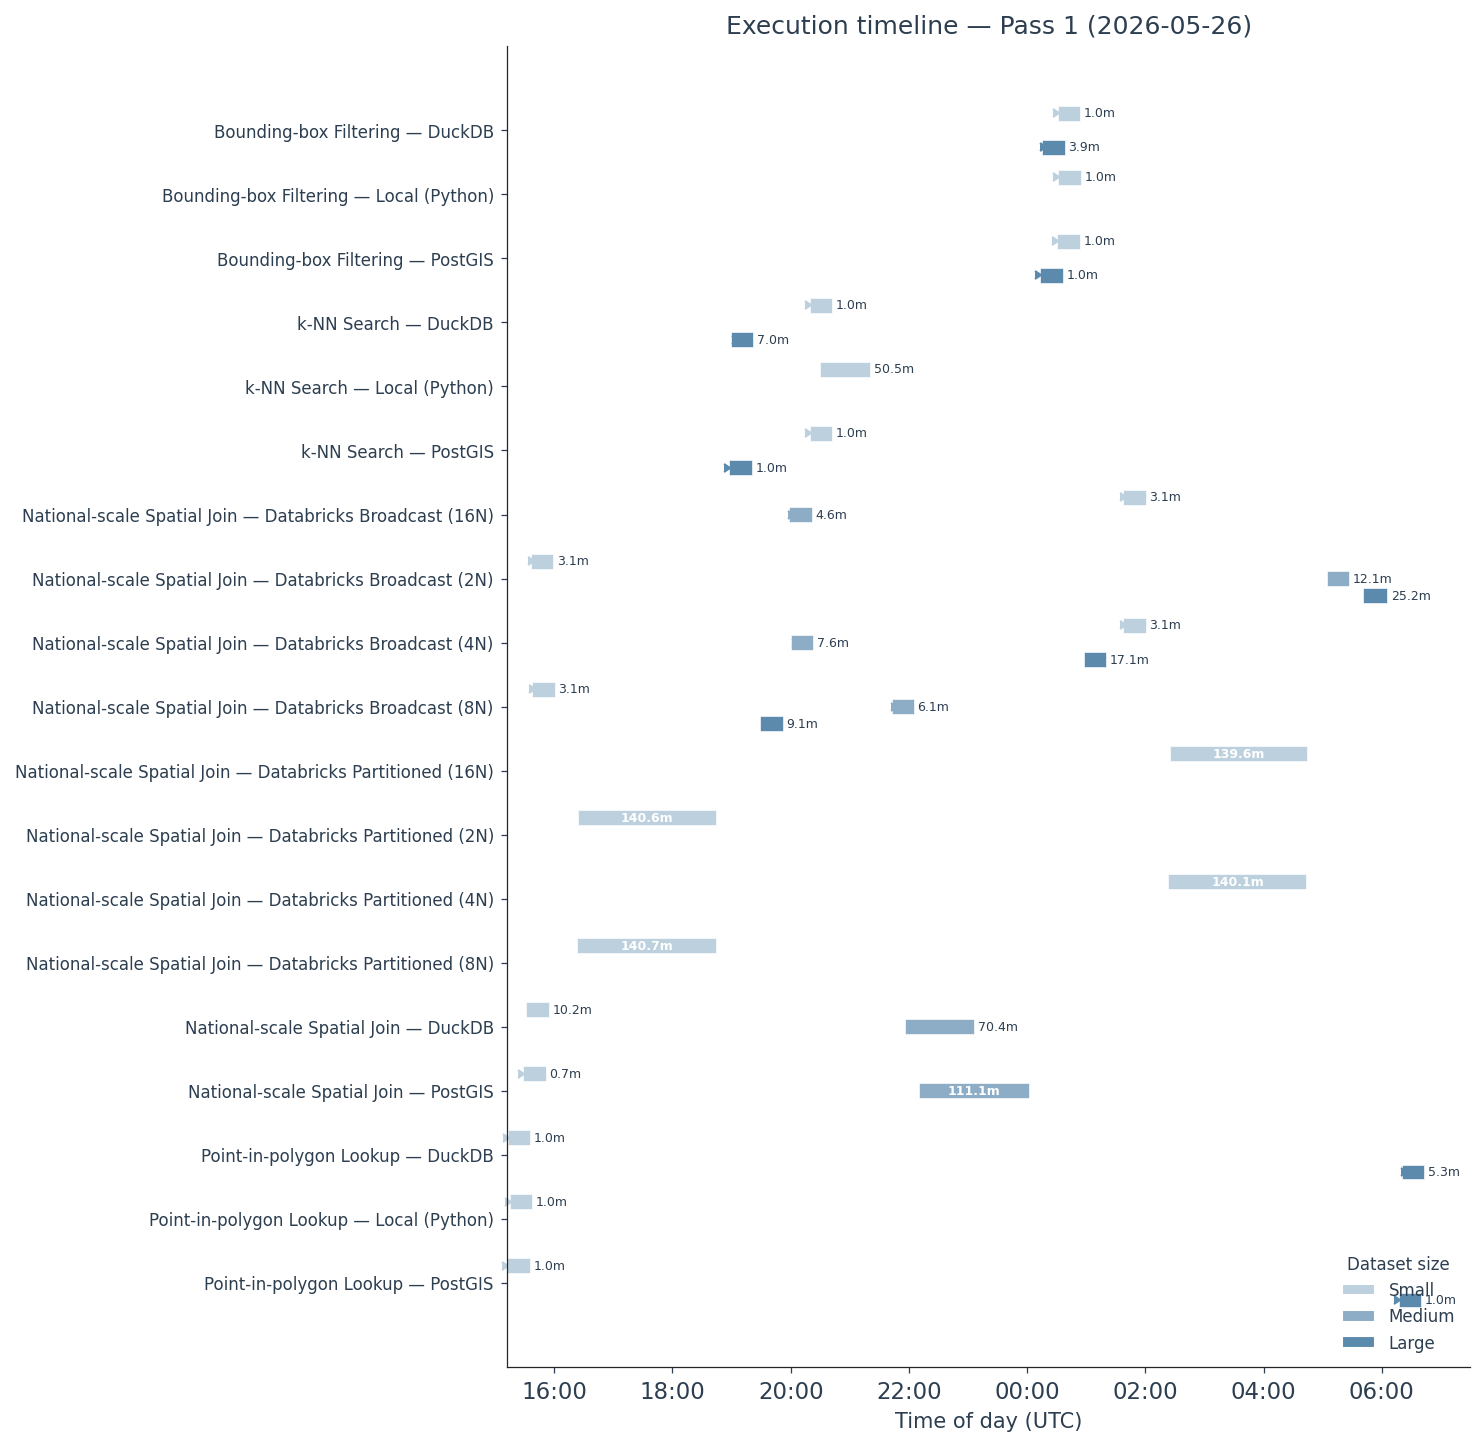

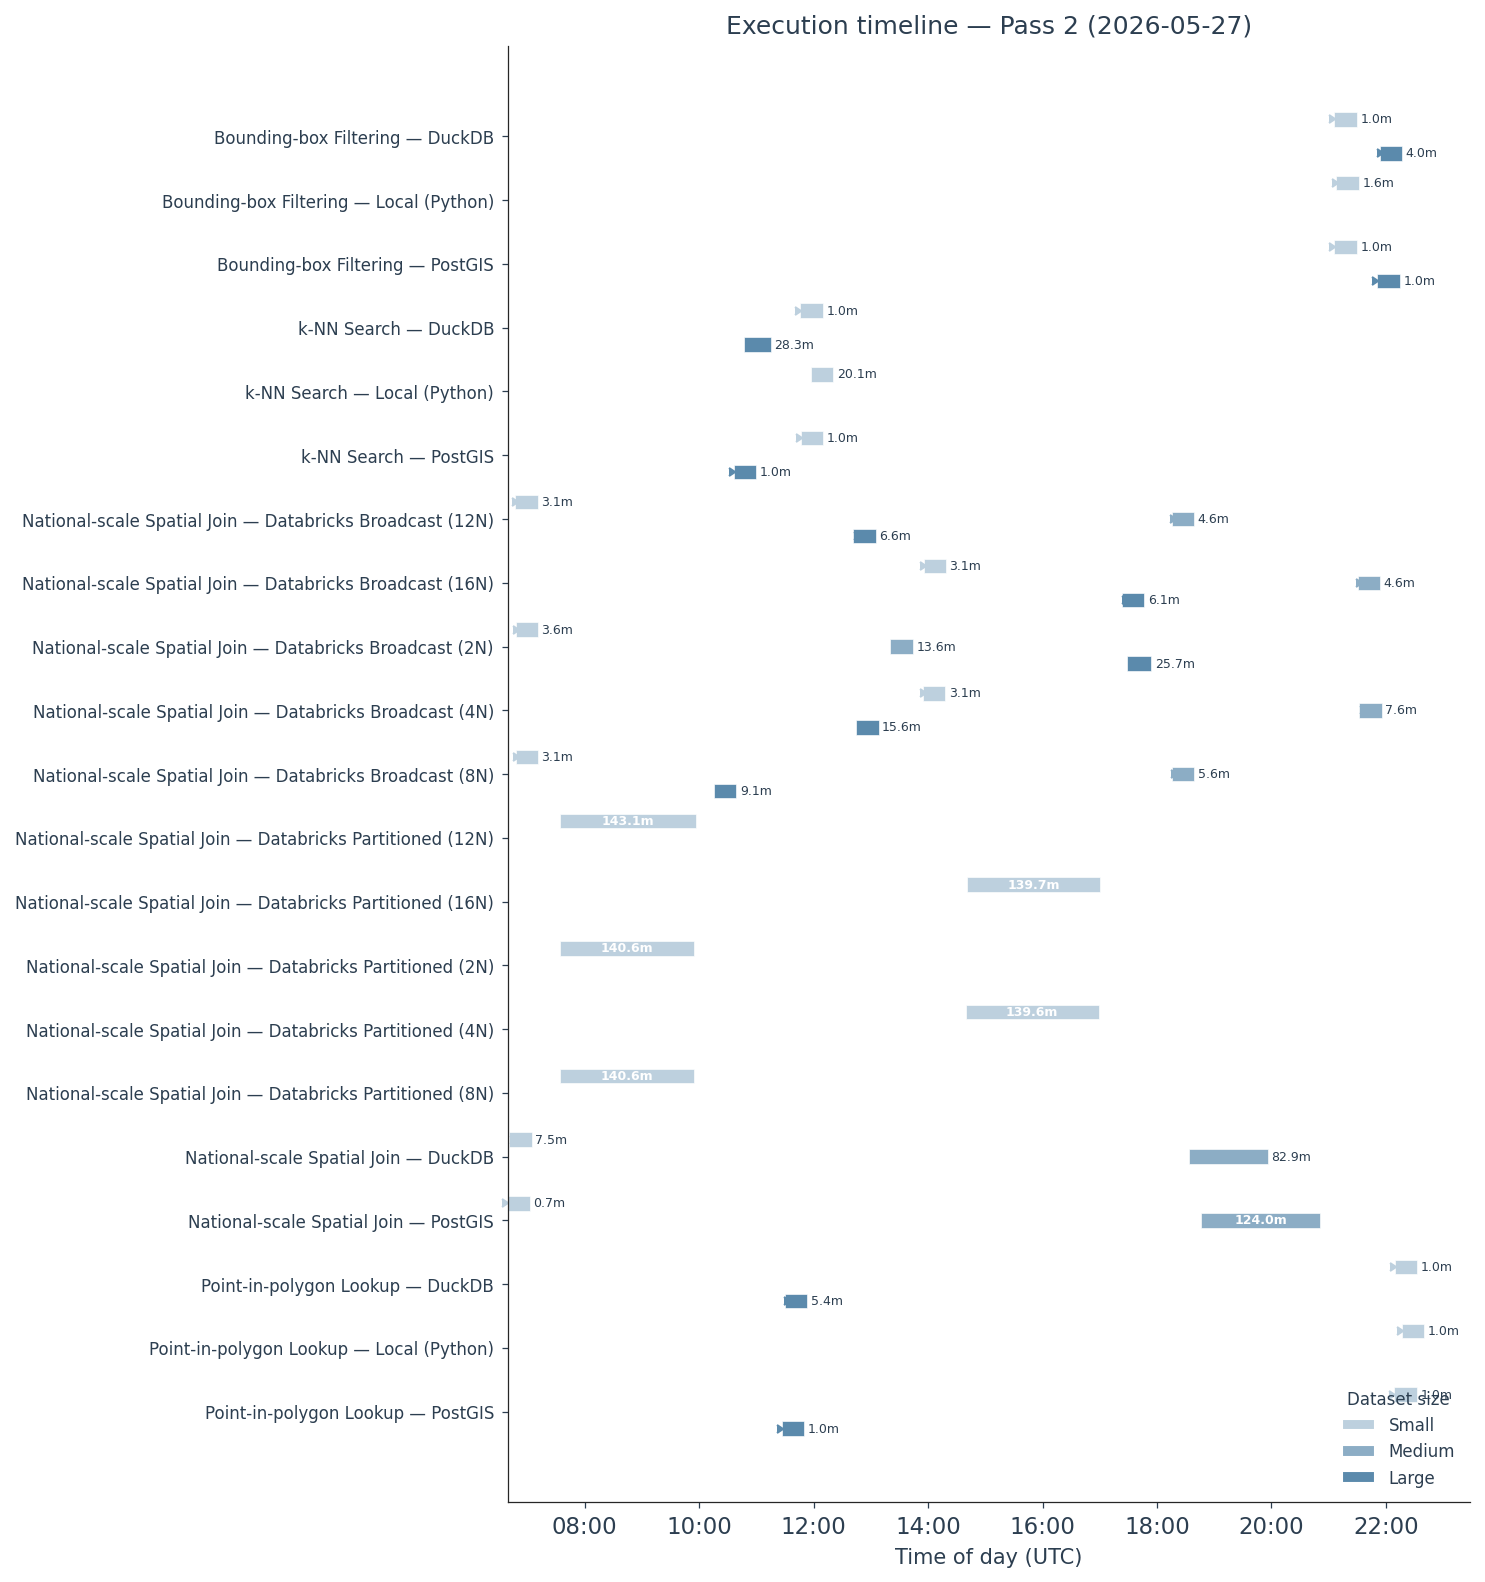

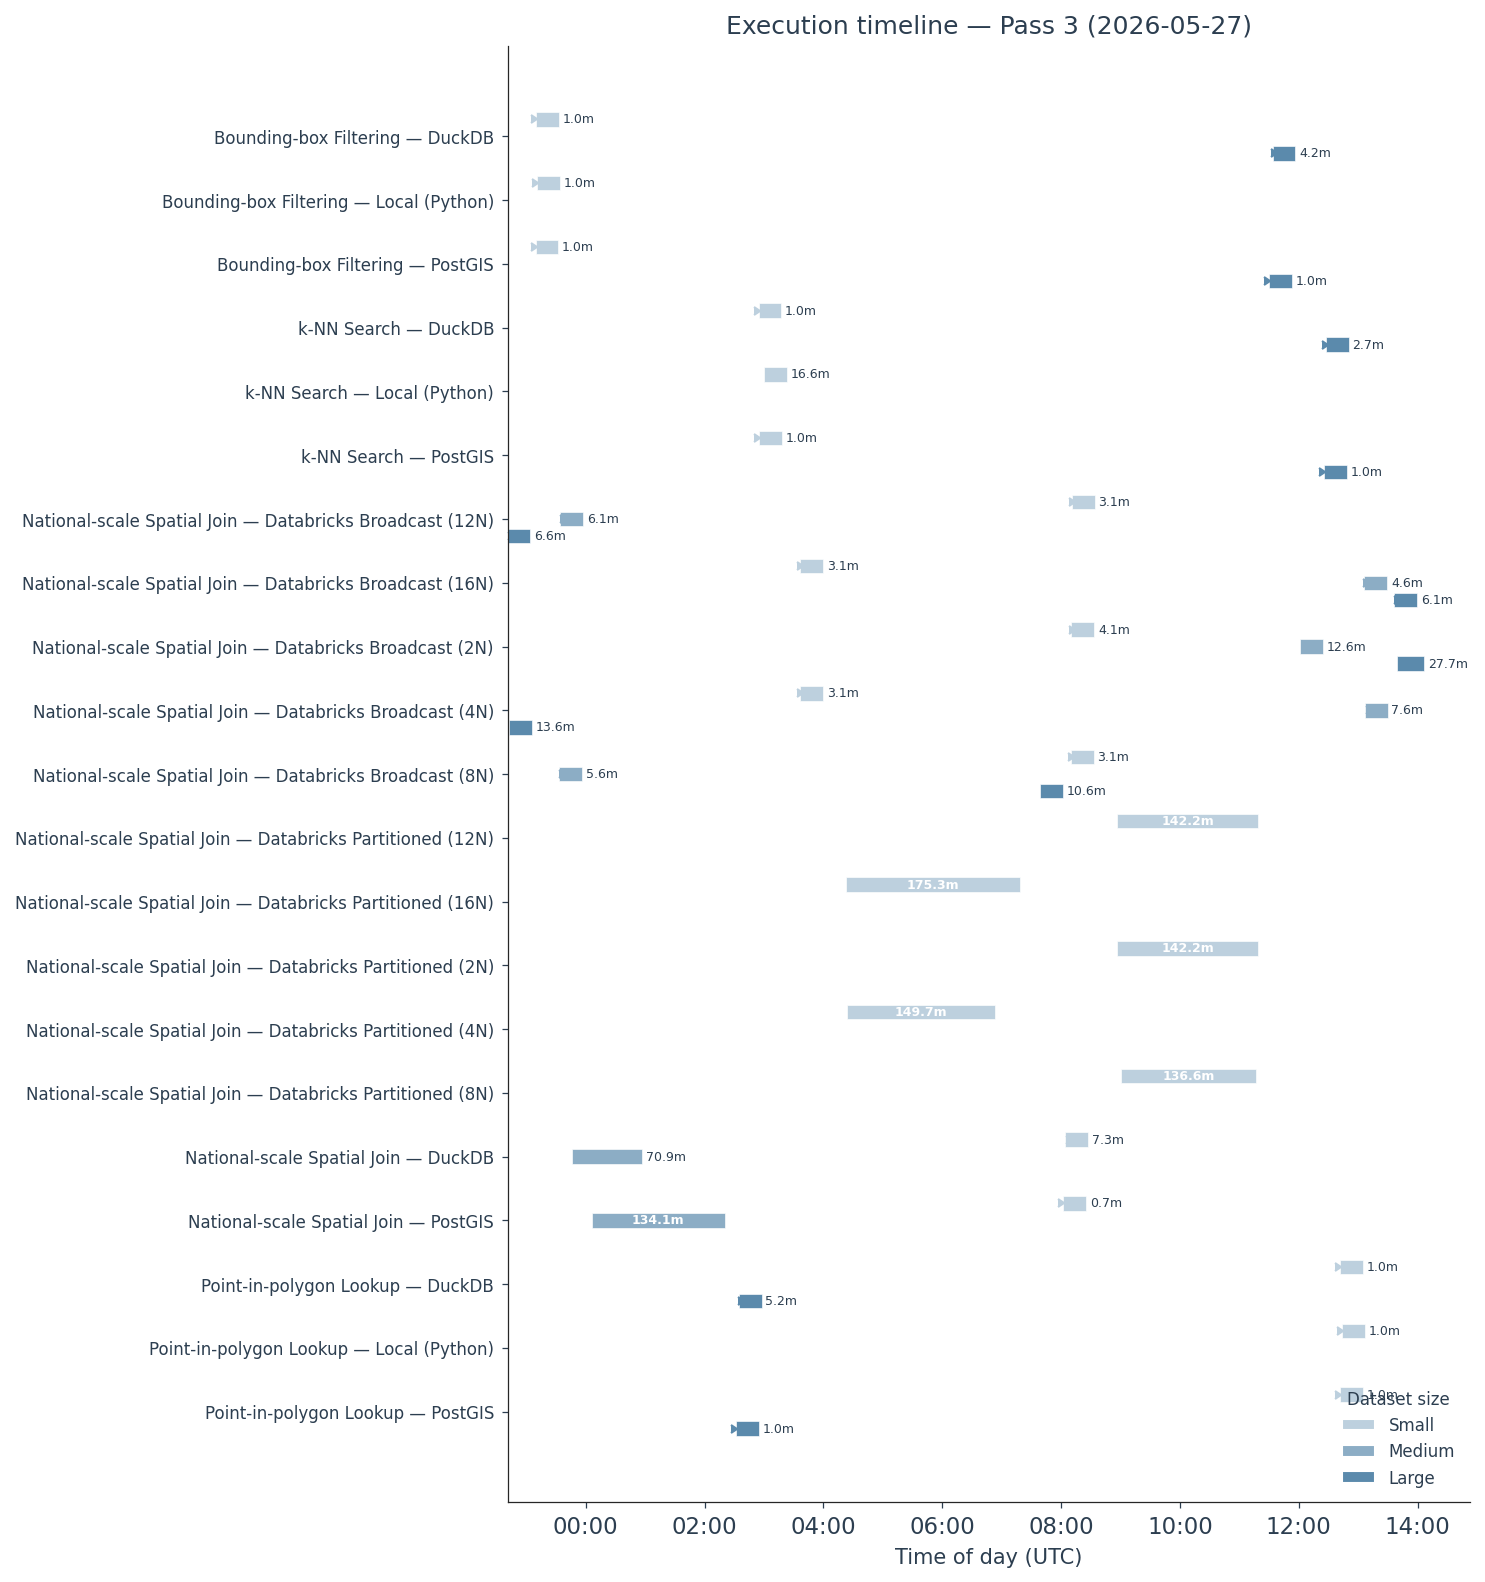

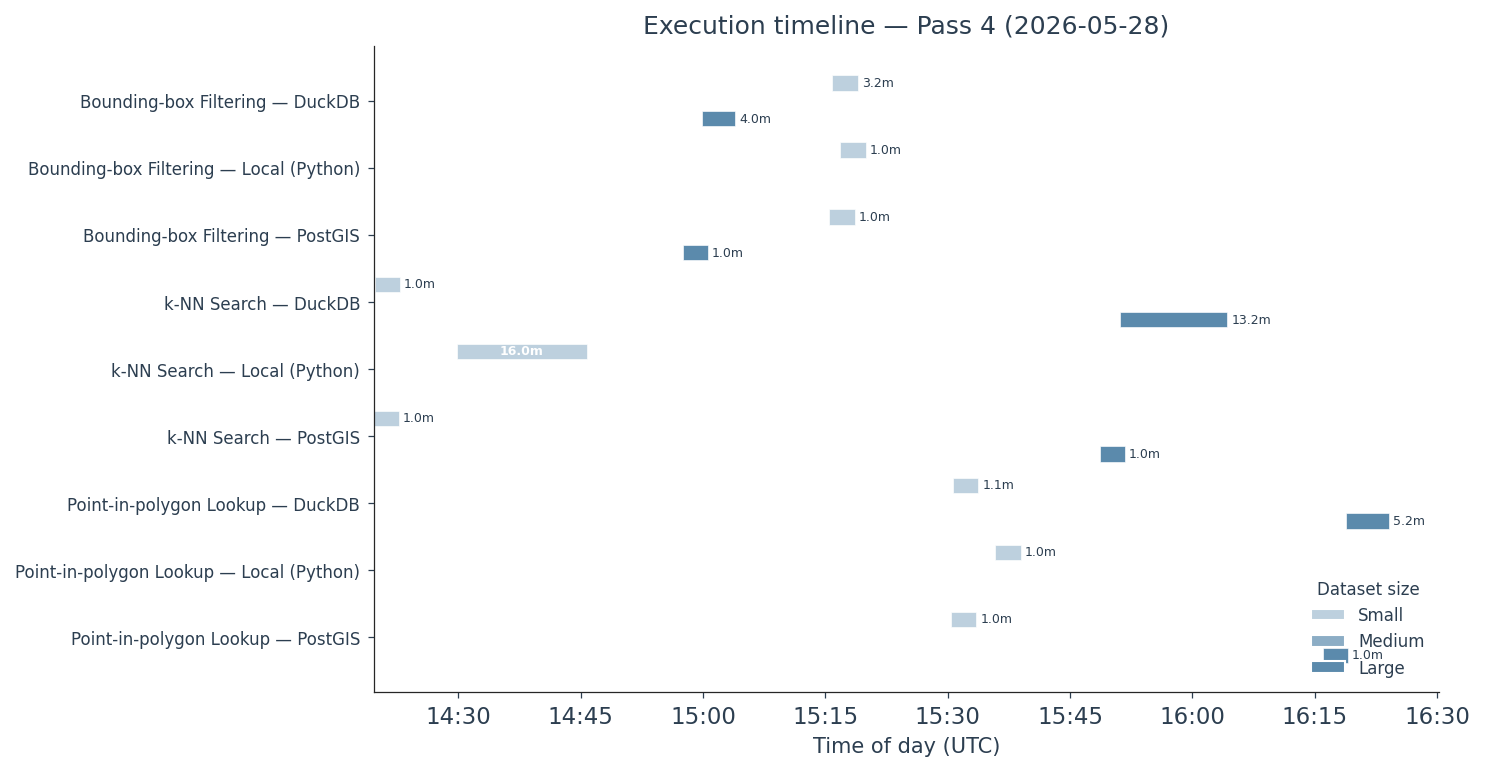

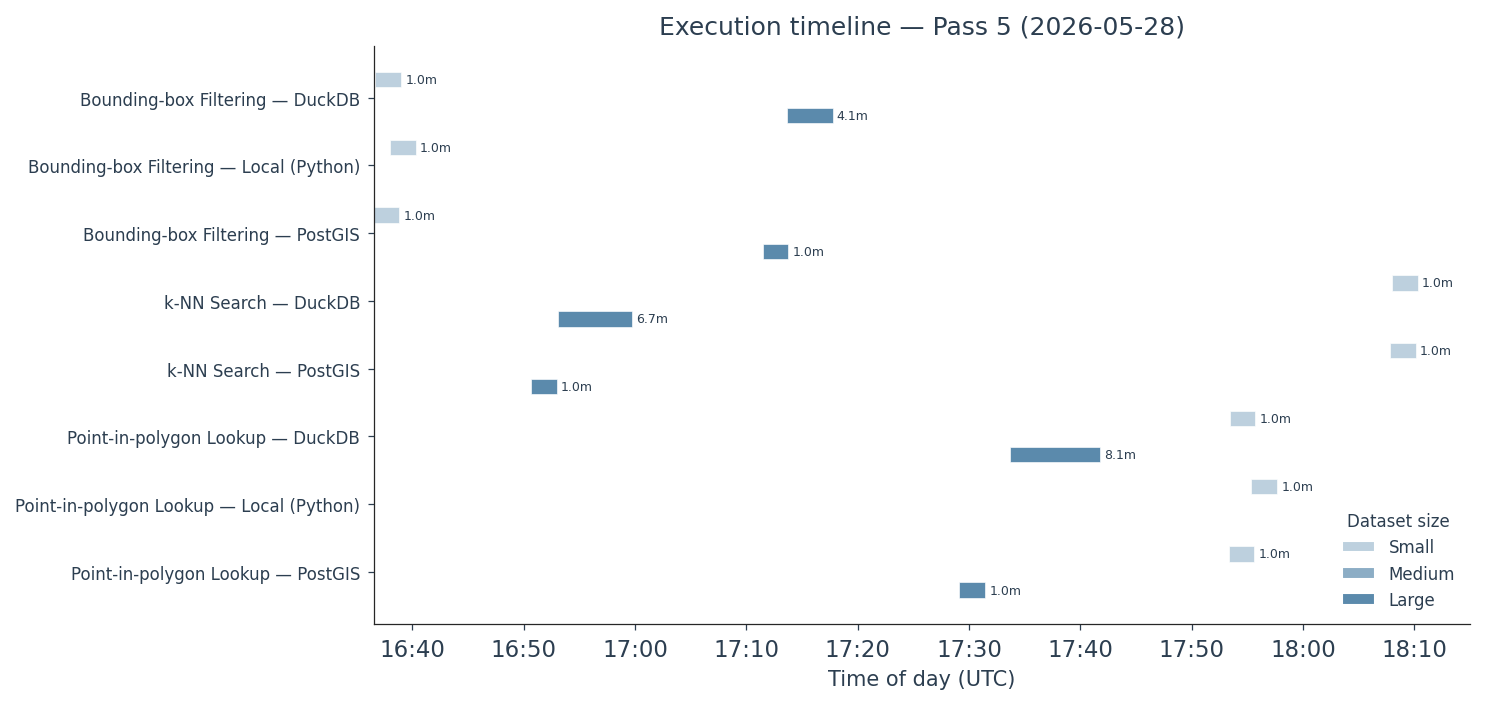

In [4]:
plot_execution_timeline(samples_df, style, FIGURES_DIR)